(2500, 5)

,cpu_speed,volts,cpu_pct,load_avg,temp
2350,1.500019,0.7500,0.0,5.87,52.1
2339,2.400034,0.8915,1.9,6.38,53.8
2259,2.400034,0.8915,93.7,6.99,59.8
1241,1.500013,0.8915,0.9,0.60,44.4
147,2.400024,0.8915,9.2,0.96,47.7


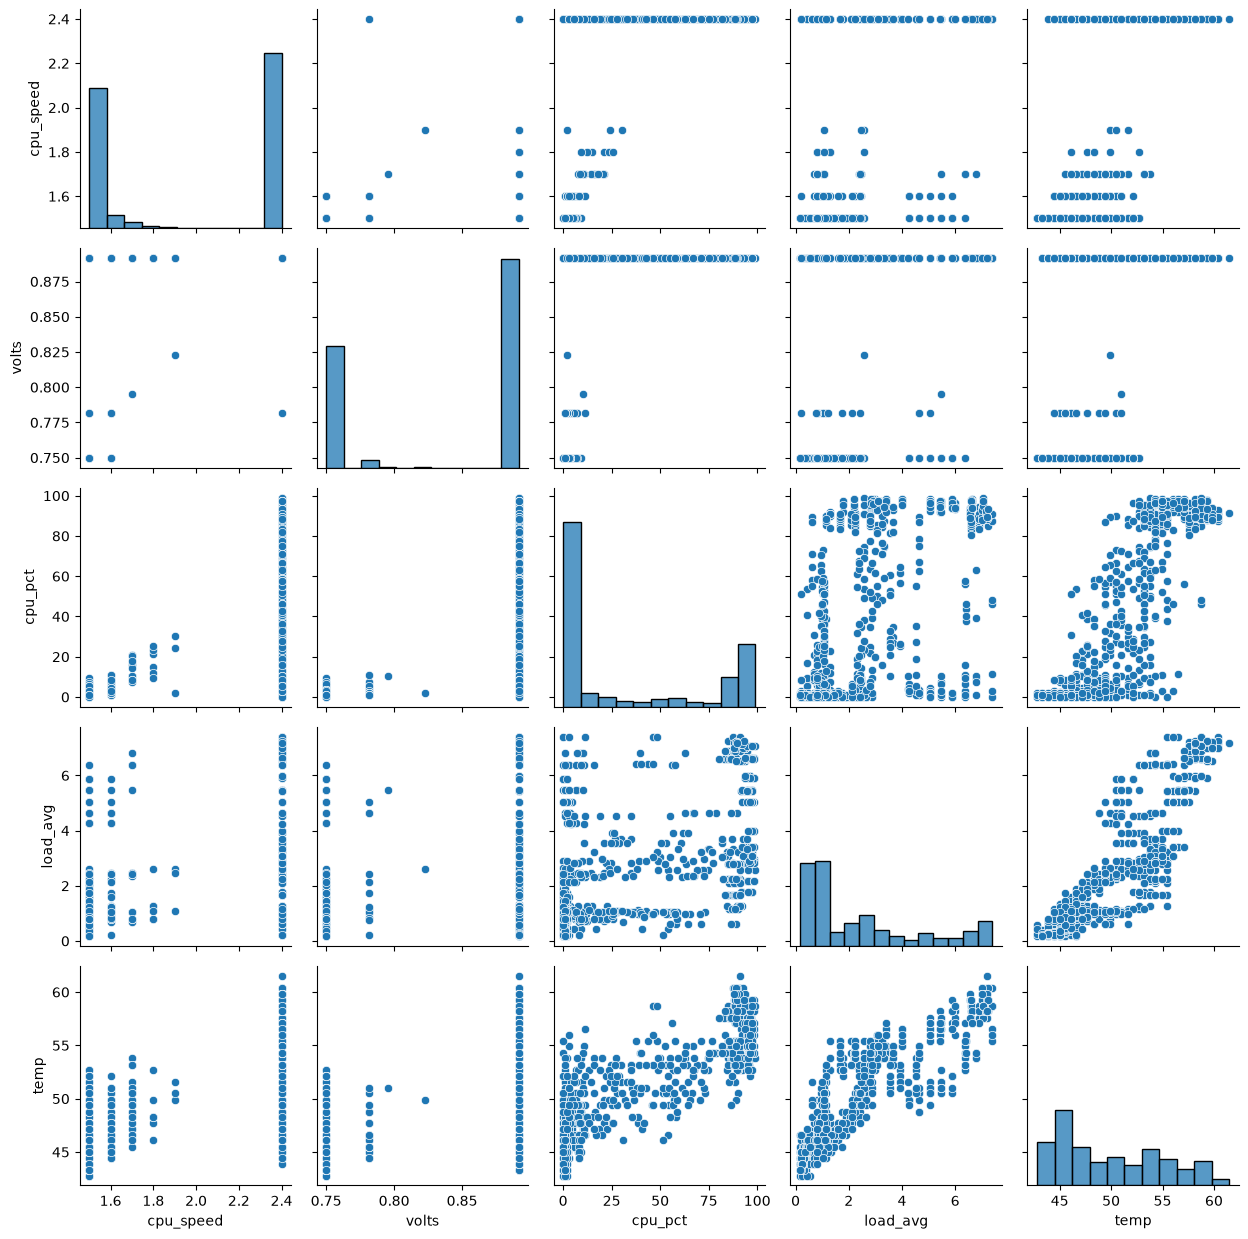

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("readings-sample.csv", on_bad_lines='error')

# Show the shape of the DataFrame and a random sample of 5 rows
display(df.shape, df.sample(5))

# Display a scatter plot matrix of the data
sns.pairplot(df.sample(1000), kind="scatter", diag_kind="hist")
plt.tight_layout() 
plt.show()

(2496, 5)


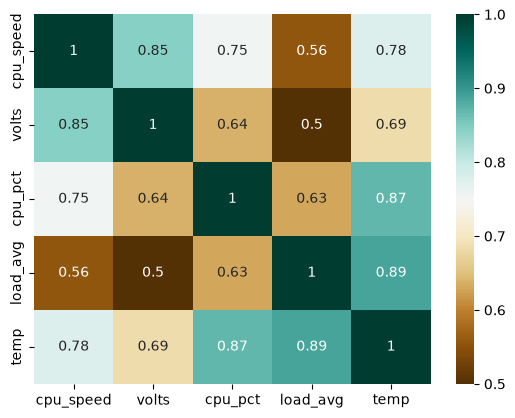

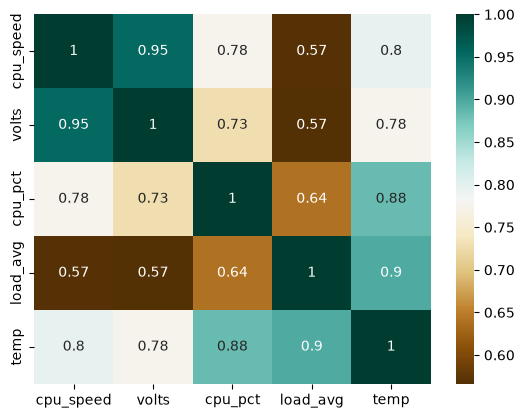

In [2]:
# Add a 5-point rolling average to smooth noise
df_adjusted = df.copy()
df_adjusted = df_adjusted.rolling(5).mean()

# Because of the rolling average, the first 4 rows will have NaN
# values. We can drop these rows.
df_adjusted = df_adjusted.dropna()
print(df_adjusted.shape)

# Display correlation for the original and adjusted DataFrames.
sns.heatmap(df.corr(), annot=True, cmap='BrBG')
plt.show()
sns.heatmap(df_adjusted.corr(), annot=True, cmap='BrBG')
plt.show()

# Basic Linear Regression
Predicting CPU temperature from metrics using linear models.

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import HTML

def do_regression(df, features):
    
    # Separate the independent and dependent variables.
    X = df[features]
    y = df.temp

    # Split the data into training and test sets.
    X_train, X_test, y_train, y_test = \
        train_test_split(X, y, random_state=42)

    # Create and fit the model.
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Plot the test data vs the model's predictions.
    y_pred = model.predict(X_test)
    sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.2})
    plt.xlabel('Actual temperature')
    plt.ylabel('Predicted temperature')
    plt.title(f"Feature(s): {', '.join(features)}")
    # plt.tight_layout()
    # plt.savefig(f"regression_{'_'.join(features)}.png")
    plt.show()

    # We want a low mean squared error and a coefficient of 
    # determination (R^2) as close to 1 as possible.
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    display(HTML(f"<b>Mean Squared Error:</b> {mse}"))
    display(HTML(f"<b>R2 score:</b> {r2}"))

    # Show some model stats
    display(HTML(f"<b>Coefficients:</b> {model.coef_}"))
    display(HTML(f"<b>Intercept:</b> {model.intercept_}"))

    # Pick and test a few samples
    test_val = X_test.sample(3)
    prediction = model.predict(test_val)
    display(HTML(f"<b>Test samples:</b>"))
    display(HTML(test_val.to_html(index=False)))
    display(HTML(f"<b>Predictions:</b> {prediction}"))


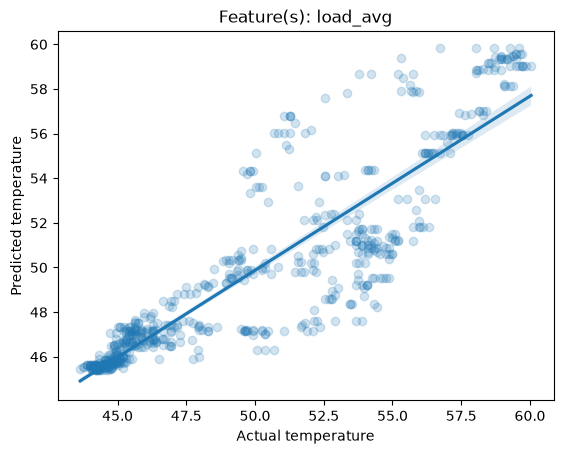

load_avg
0.96
3.34
6.99


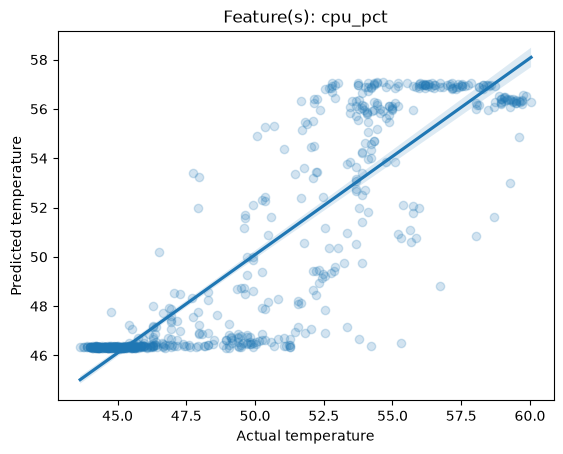

cpu_pct
96.12
96.64
90.92


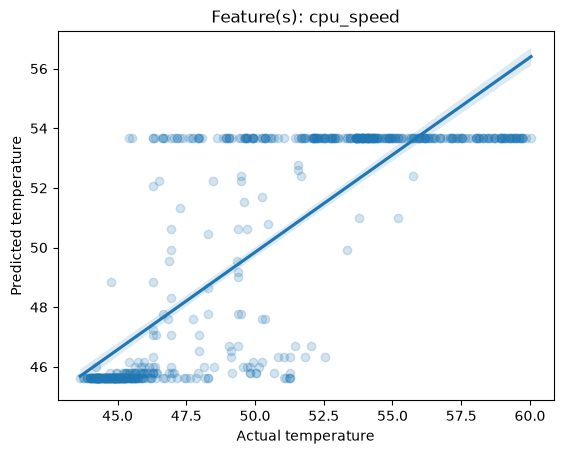

cpu_speed
1.500018
1.500012
1.520019


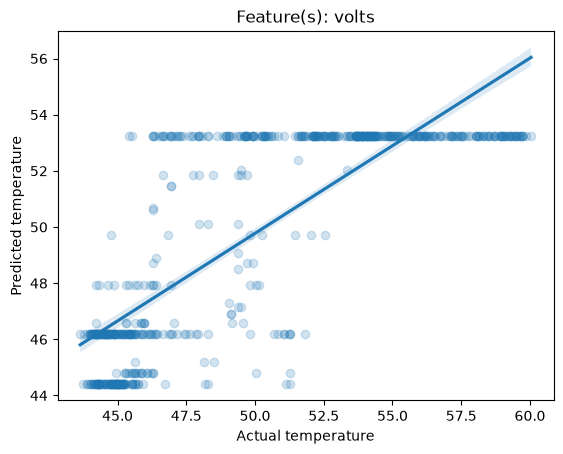

volts
0.7783
0.7563
0.8915


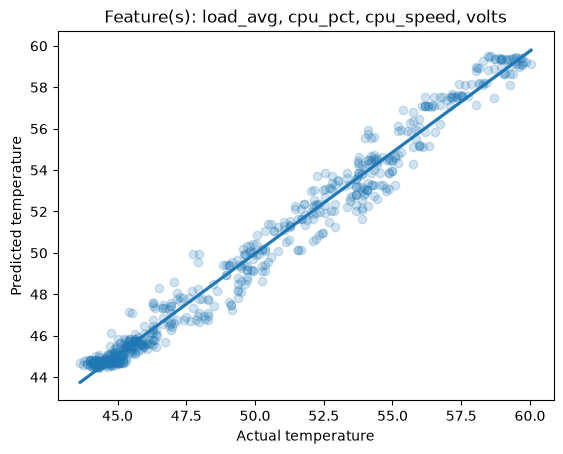

load_avg,cpu_pct,cpu_speed,volts
3.340,75.68,2.400026,0.8915
1.140,1.10,1.500017,0.7783
2.412,62.24,2.400025,0.8915


In [4]:
# Specify the independent variables, also known as "features".
linreg_features = ["load_avg", "cpu_pct", "cpu_speed", "volts"]

# Build a single-variable regression model for each feature,
# then build a multiple-variable model for all the features.
for fc in linreg_features:
    do_regression(df_adjusted, [fc])
do_regression(df_adjusted, linreg_features)

# Basic Logistic Regression

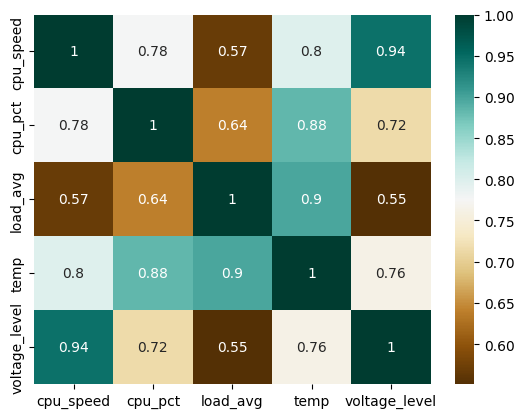

In [ ]:
from sklearn.pipeline import make_pipeline 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

def calculate_voltage_level(x):
    return 1 if x >= .825 else 0


df2 = df_adjusted.copy() # make a copy before changing anything

# Convert cpu voltage into a low/high indicator.
df2["voltage_level"] = df2.volts.apply(calculate_voltage_level)
df2.drop("volts", axis=1, inplace=True) # remove volts column

# Visualise correlation
sns.heatmap(df2.corr(), annot=True, cmap='BrBG')
plt.savefig("correlation_heatmap.png")
plt.show()


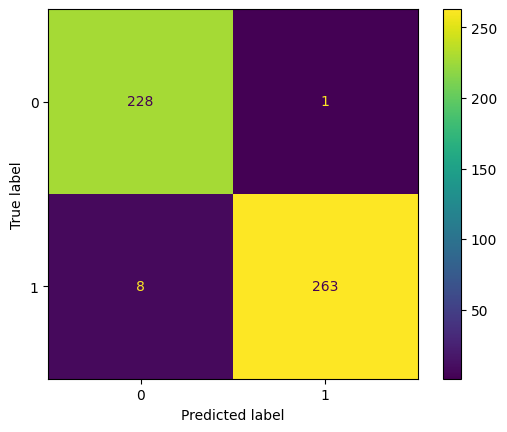

In [38]:
# Prepare the data
features = ["cpu_speed", "cpu_pct"]
X = df2[features].values
y = df2.voltage_level.values
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=.2, random_state=42)

# Scale the data and run the regression.
logreg = make_pipeline(StandardScaler(), 
                       LogisticRegression()) 
logreg.fit(X_train, y_train)

# Generate predictions based on the test inputs
y_pred = logreg.predict(X_test)

# Evaluate the model with a confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=logreg.classes_)
disp.plot()
plt.show()